In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import namedtuple

RUPTURE_POSITIONS = [115, 110, 105, 100, 95, 90, 85, 80, 75, 65, 55, 45, 35, 25, 15, 5]
mesh_size = 2.0
normal_stress = 10.0
Spring_stiffness = 3000


def norm(array: np.ndarray) -> np.ndarray:
    """Normalize the array to the range [0, 1]."""
    return (array - np.min(array)) / (np.max(array) - np.min(array))

SPRING_ENERGIES = []
CENTER_BLOCK_ENERGIES = []
LEFT_BLOCK_ENERGIES = []
RIGHT_BLOCK_ENERGIES = []
STEEL_PLATE_ENERGIES = []

for RUPTURE_POSITION in RUPTURE_POSITIONS:
    filename = f'./MeshDC/{mesh_size}mm/strain-energy-{RUPTURE_POSITION}.npz'
    if not os.path.exists(filename):
        print(f"[WARNING] File {filename} not found. Skipping.")
        continue

    data = np.load(filename)
    SPRING_ENERGIES.append(data.get('ELSE-Spring', np.nan))
    CENTER_BLOCK_ENERGIES.append(data.get('ELSE-Center-Block', np.nan))
    LEFT_BLOCK_ENERGIES.append(data.get('ELSE-Left-Block', np.nan))
    RIGHT_BLOCK_ENERGIES.append(data.get('ELSE-Right-Block', np.nan))
    STEEL_PLATE_ENERGIES.append(data.get('ELSE-Steel-Plate', np.nan))


SPRING_ENERGIES = np.array(SPRING_ENERGIES)
CENTER_BLOCK_ENERGIES = np.array(CENTER_BLOCK_ENERGIES)
LEFT_BLOCK_ENERGIES = np.array(LEFT_BLOCK_ENERGIES)
RIGHT_BLOCK_ENERGIES = np.array(RIGHT_BLOCK_ENERGIES)
STEEL_PLATE_BLOCK_ENERGIES = np.array(STEEL_PLATE_ENERGIES)

SPRING_ENERGIES     = SPRING_ENERGIES
BLOCK_ENERGIES      = CENTER_BLOCK_ENERGIES + LEFT_BLOCK_ENERGIES + RIGHT_BLOCK_ENERGIES
SIDE_BLOCK_ENERGIES = LEFT_BLOCK_ENERGIES + RIGHT_BLOCK_ENERGIES
SYSTEM_ENERGIES     = BLOCK_ENERGIES + SPRING_ENERGIES + STEEL_PLATE_ENERGIES

In [2]:
ArrayEntry = namedtuple("ArrayEntry", ["data", "label"])

data_dict = {
    "spring_energies": ArrayEntry(SPRING_ENERGIES, "Spring Energies"),
    "block_energies": ArrayEntry(BLOCK_ENERGIES, "Block Energies"),
    "side_block_energies": ArrayEntry(SIDE_BLOCK_ENERGIES, "Side Block Energies"),
    "system_energies": ArrayEntry(SYSTEM_ENERGIES, "System Energies"),
}

In [3]:
PLOT_KEYS = ["spring_energies", "block_energies", "side_block_energies", "system_energies"]

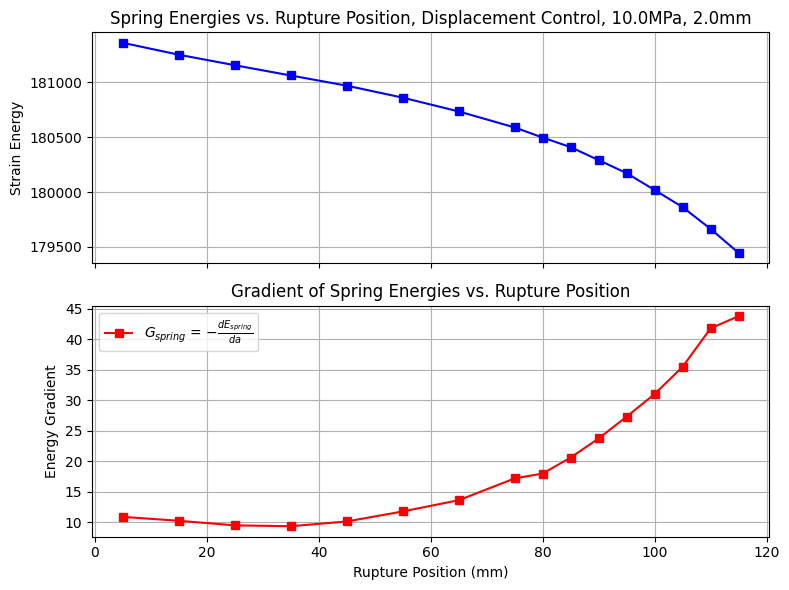

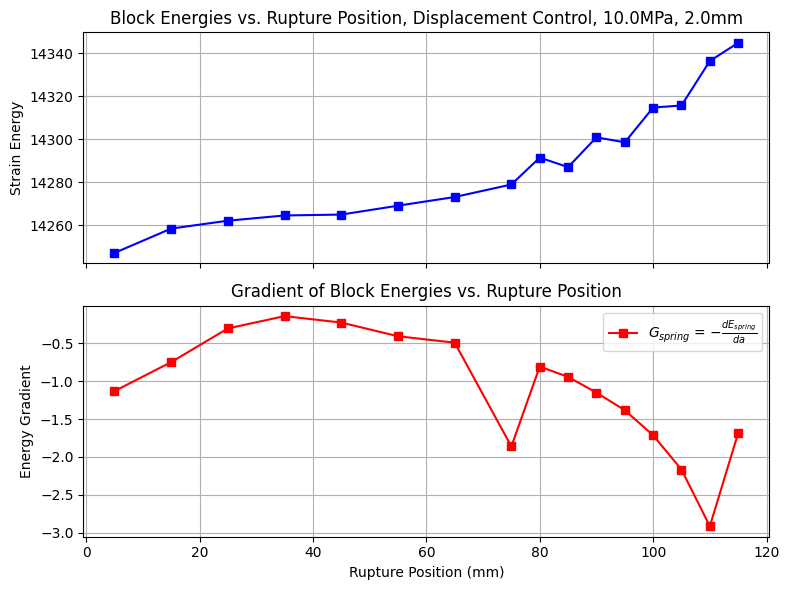

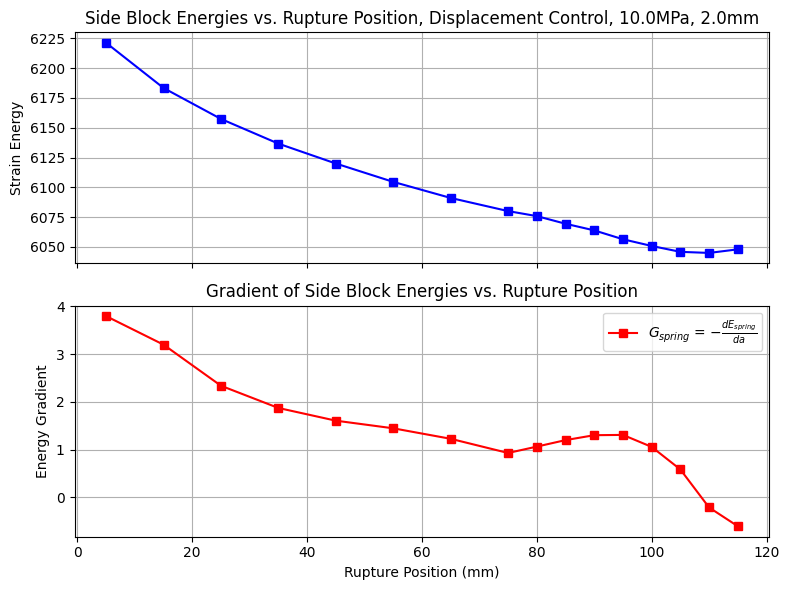

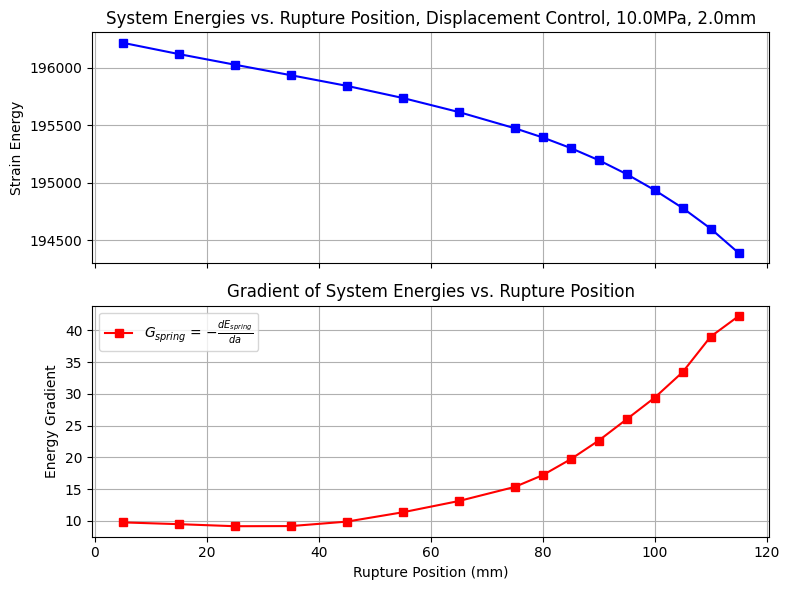

In [4]:
for key in PLOT_KEYS:

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    ax1.plot(RUPTURE_POSITIONS, data_dict[key].data, 's-', color = "blue", label=data_dict[key].label)
    ax1.set_ylabel("Strain Energy")
    ax1.set_title(f"{data_dict[key].label} vs. Rupture Position, Displacement Control, {normal_stress:.1f}MPa, {mesh_size}mm")
    ax1.grid(True)
    # ax1.legend()

    ax2.plot(RUPTURE_POSITIONS, -np.gradient(data_dict[key].data, RUPTURE_POSITIONS), 's-', label=r'$G_{spring}$ = $-\frac{dE_{spring}}{da}$', color='red')
    ax2.set_xlabel("Rupture Position (mm)")
    ax2.set_ylabel("Energy Gradient")
    ax2.set_title(f"Gradient of {data_dict[key].label} vs. Rupture Position")
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f'./Energy/Plots/SS-{key}.pdf', dpi=300)
    plt.savefig(f'./Energy/Plots/PNG/SS-{key}.png', dpi=300)
    plt.show()
    plt.close()